# **PORTFOLIO CHOICE WITH A SPARSE AUTOENCODER** 

|  |  |
|:---|:---|
|**Reading Time** | 90  minutes |
|**Prior Knowledge** | Neural Networks, machine learning, PCA, linear algebra  |
|**Keywords** | Autoencoder, portfolio choice |


---

## **1. INTRODUCTION**

In this notebook, we will build and train autoencoder models using the same data that we exploited in Lesson 2's notebook and some of the tools that we discussed in Lesson 3.

Additionally, we will implement the predictions of the autoencoder model to design a portfolio of stocks that maximizes the expected risk-weighted return in sample and compare its performance with other, more naïve strategies.

First of all, we load the libraries and data that we need for this notebook. 

In [8]:
import numpy as np
import pandas as pd

In [9]:
import tensorflow as tf

In [10]:
import yfinance as yf

tickers = [
    "AAPL",
    "MSFT",
    "GOOG",
    "AMZN",
    "TSLA",
    "TCEHY",
    "NVDA",
    "TSM",
    "META",
    "BABA",
    "ASML",
    "AVGO",
    "ORCL",
    "CSCO",
    "ADBE",
    "CRM",
    "NFLX",
    "TXN",
    "QCOM",
    "SAP",
]
df = pd.DataFrame()
for tick in tickers:
    ydata = yf.download(tick, start="2017-01-01", end="2022-12-31")
    data = ydata["Adj Close"].pct_change()
    df[tick] = data[1:]
df.index = pd.to_datetime(ydata.index[1:], format="%Y%m%d")
df = df.dropna(axis=1)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [11]:
train_size = int(0.8 * df.shape[0])
Y_train = df[: train_size + 1].to_numpy()
Y_test = df[train_size + 1 :].to_numpy()

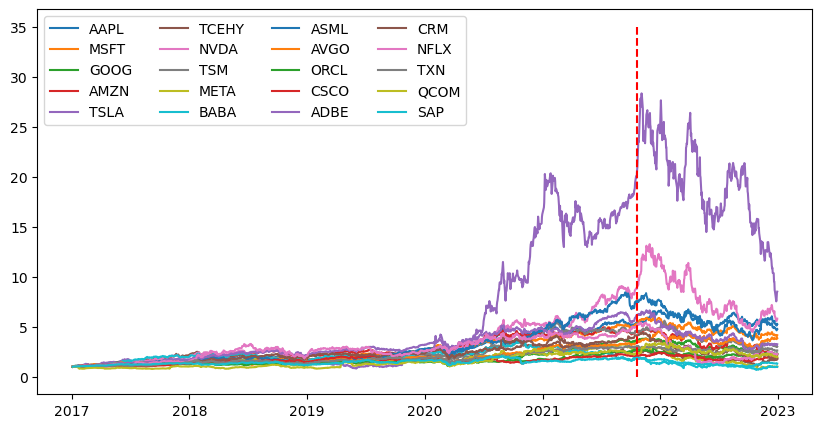

In [12]:
import matplotlib.pyplot as plt

df_ret = 1 + df
for tick in tickers:
    df_ret[tick] = df_ret[tick].cumprod()
plt.figure(figsize=(10, 5))
plt.plot(df_ret)
plt.plot([df.index[train_size + 1], df.index[train_size + 1]], [0, 35], "r--")
plt.legend(tickers, loc="upper left", ncol=4)
plt.show()

## **2. BUILDING AND TRAINING A SPARSE AUTOENCODER**

We will design a portfolio based on the predictions of an autoencoder model with a loss function that includes a regularization term on the value of the factors generated by the model. 

In TensorFlow, we add an L1-regularizer in the bottleneck "tf.keras.regularizers.l1(l1weight)", where "l1weight" is a hyperparameter that governs the degree of regularization on the factor space. This parameter will determine the actual dimension of the bottleneck, without us having to impose it beforehand.

In [13]:
class sparse_autoencoder(tf.keras.Model):
    def __init__(self, output_dim, bottleneck_dim=1, l1weight=0.0):
        super(sparse_autoencoder, self).__init__()
        self.output_dim = output_dim
        self.bottleneck_dim = bottleneck_dim
        self.l1weight = l1weight
        initializer = tf.keras.initializers.GlorotUniform()
        # Set the activity regularizer that will generate the sparsity of factors
        activity_regularizer = tf.keras.regularizers.l1(l1weight)
        # Build the encoding layer, including the activity regularizer
        self.encoder = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(
                    bottleneck_dim,
                    activity_regularizer=activity_regularizer,
                    kernel_initializer=initializer,
                    bias_initializer=tf.keras.initializers.Zeros(),
                )
            ]
        )
        # Build the decoding layer
        self.decoder = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(
                    output_dim,
                    kernel_initializer=initializer,
                    bias_initializer=tf.keras.initializers.Zeros(),
                )
            ]
        )

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Let's compile and train the model. We set the L1-regularization parameter to $\lambda_1=0.0025$.

In [14]:
# Set the bottleneck size equal to the input size
nlatent = Y_train.shape[1]
# Set the parameter on the L1 activity-regularization term
l1weight = 0.0025
# Choose the proportion of training data used for validation
val_split = 0.2
# Determine early stopping criterion
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50)
# Choose optimizer
adam = tf.keras.optimizers.Adam(learning_rate=1e-4)
# Build and compile the model
model = sparse_autoencoder(Y_train.shape[1], nlatent, l1weight)
model.compile(optimizer=adam, loss="mse")
# Train the model
model.fit(
    x=Y_train,
    y=Y_train,
    batch_size=32,
    epochs=10,
    validation_split=val_split,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


31/31 [==============================] - 2s 27ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 2/10
31/31 [==============================] - 0s 13ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 3/10
31/31 [==============================] - 0s 16ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 4/10
31/31 [==============================] - 0s 14ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 5/10
31/31 [==============================] - 0s 14ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 6/10
31/31 [==============================] - 0s 14ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 7/10
31/31 [==============================] - 0s 16ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 8/10
31/31 [==============================] - 0s 13ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/10
31/31 [==============================] - 0s 13ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 10/10
31/31 [==============================] - 0s 17ms/step - loss: 0.0014 - val_loss: 0.0013


By plotting the time series of the factors generated by the model, we can observe how the regularization term shrinks the dimensionality of the bottleneck. The model is forced to generate a number of latent factors with lower dimensionality than the data and that are relevant to explain its variation.

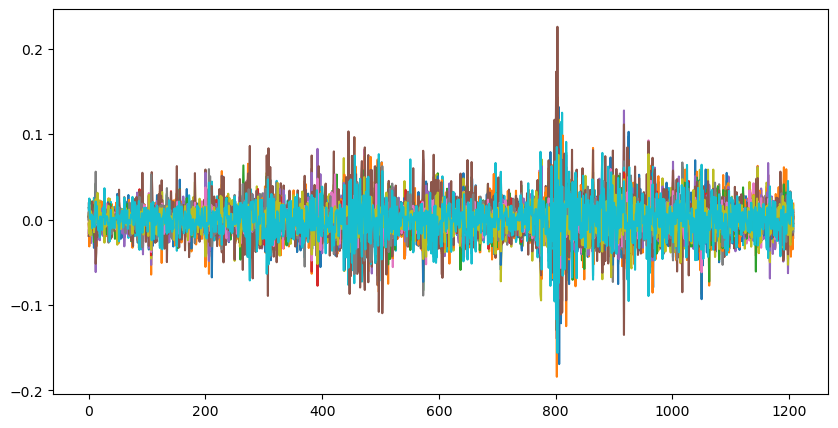

In [15]:
factors = model.encoder(Y_train).numpy()
plt.figure(figsize=(10, 5))
plt.plot(factors)
plt.show()

Below, we plot the time series of each factor. Observe how, out of 20 possible dimensions, the addition of the regularization term enables us to "drop" some dimensions. Notice the resemblance of this regularization technique with the L1-regularization of weights in MLPs. In that setup, we were interested in filtering a set of input features that are relevant for predictions. In the autoencoder setup, the activity regularization chooses a few factors that are relevant at explaining the variation in the data.

You can play with the parameter $\lambda_1$ above and observe its impact on the number of factors generated and the performance of the model. Notice also that the results depend on the random seed that is used to initialize the model's parameters while training.

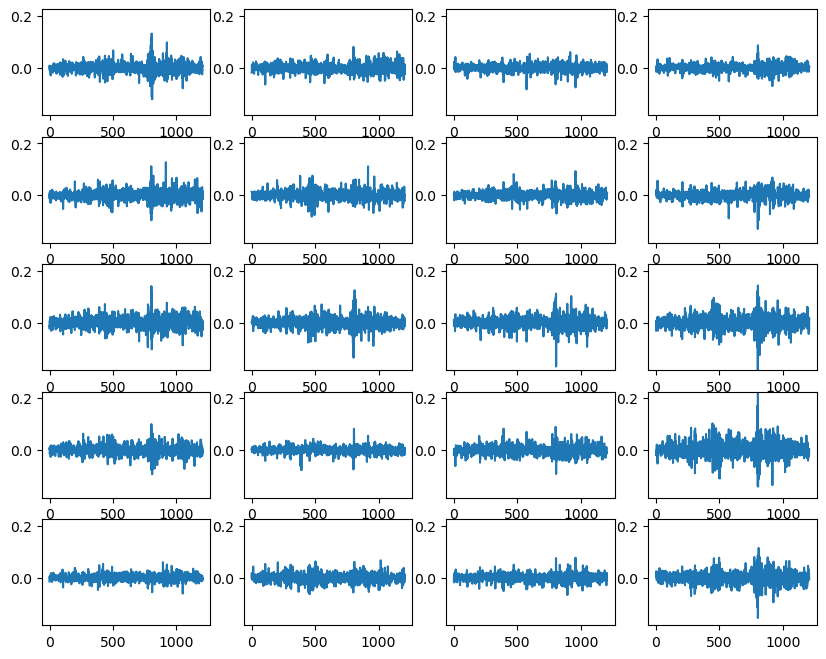

In [16]:
custom_ylim = [np.min(factors), np.max(factors)]
fig, axs = plt.subplots(5, 4, figsize=(10, 8))
for i in range(5):
    axs[i, 0].plot(factors[:, 0 + i * 4])
    axs[i, 0].set_ylim(custom_ylim)
    axs[i, 1].plot(factors[:, 1 + i * 4])
    axs[i, 1].set_ylim(custom_ylim)
    axs[i, 2].plot(factors[:, 2 + i * 4])
    axs[i, 2].set_ylim(custom_ylim)
    axs[i, 3].plot(factors[:, 3 + i * 4])
    axs[i, 3].set_ylim(custom_ylim)

In terms of reconstruction performance, the regularization parameter $\lambda_1$ is quite small, so the reconstruction errors from this model should be below those in Lesson 2 using an undercomplete autoencoder with three factors. This is a natural outcome because increasing the number of latent factors should increase the proportion of the variance explained by the model.

In [17]:
Y_pred = model.predict(Y_train, verbose=0)
error = np.sum((Y_train - Y_pred) ** 2) / np.sum((Y_train - np.mean(Y_train)) ** 2)
print("Reconstruction error in training sample", error)
Y_pred = model.predict(Y_test, verbose=0)
error_oos = np.sum((Y_test - Y_pred) ** 2) / np.sum((Y_test - np.mean(Y_test)) ** 2)
print("Reconstruction error in test sample", error_oos)

Reconstruction error in training sample 1.3578125165774155
Reconstruction error in test sample 1.3662343677903814


## **3. PORTFOLIO CHOICE USING THE PREDICTIONS OF THE AUTOENCODER**

Now we are going to use the trained autoencoder to choose an "optimal" portfolio of stocks. Based on the estimated exposures of each stock to the factors that determine the comovement in stock returns, we can design a diversified portfolio that maximizes the expected risk-weighted returns. Let's formally describe this.







Notice that the decoding layer of the autoencoder implies that we can model the returns of a stock $i$ at time $t$ as:
$$
r_{it} = \alpha_i + \beta_{i1} f_{1t} + \beta_{i2} f_{2t} + \cdots + \beta_{ik} f_{kt} + \varepsilon_{it}
$$
where $f_{1t},\ f_{2t}, ...,\ f_{kt}$ are the factors generated by the autoencoder, and $\alpha_i,\ \beta_{i1},\ \beta_{i2}, ..., \beta_{ik}$ are the trained parameters. $\varepsilon_{it}$ are zero-mean error terms. The representation above is called a linear factor model.

If we stack the observations of returns of all the stocks $i=1,...,n$ at a period $t$ in a column vector $R_t$, stock returns are given by:
$$
R_{t} = \mathbf{a} + B F_t + \mathbf{e}_{t}
$$
where (bold faces are meant to differentiate vectors from scalars):

*   $\mathbf{a}$ is an $n\times 1$ vector that includes all the trained $\alpha_i$'s
*   $B$ is an $n\times k$ matrix that includes all the trained $\beta_{ij}$'s.
*   $F_t$ is a $k\times 1$ vector of realizations of the factors.
*   $\mathbf{e}_t$ is an $n\times 1$ vector of idiosyncratic (stock-specific) errors $\varepsilon_{it}$'s

Assume that the variance of $\mathbf{e}_t$ is a diagonal $n\times n$ matrix $\Sigma_e$, while the variance of $F_t$ is denoted by the $k\times k$ matrix $\Sigma_f$. These matrices capture the variation and covariation of the factors and idiosyncratic terms over time and that we can estimate, for instance, from our autoencoder model. Thus, the expectation and variance of the return vector $R_t$ are given by
$$
E(R_t) = \mu = \mathbf{a} + BE(F_t) \\
Var(R_t) = \Sigma = B\Sigma_f  B^T + \Sigma_e
$$
The first component of the variance of returns is called the systematic component of the variance, which arises from the common latent factors that determine all the returns, depending on the stock-specific exposures to those factors included in $B$. The second component is the idiosyncratic component of the variance. This variation can be interpreted as noise, which is assumed to be stock-specific (uncorrelated across stocks).

Using the autoencoder, we can build our estimates for $\mu$ and $\Sigma$. For $\mu$, we take the average of the reconstruction of each stock return over the training sample, $E(\hat{R}_t)$. For $\Sigma$, we first compute the variance covariance matrix of the reconstructions, $\Sigma_f = Var(\hat{R}_t)$, and then we add the idiosyncratic component from the variance-covariance matrix of the reconstruction errors, $\Sigma_e=diag(Var(\mathbf{e}_t))$. Following our assumption above, we impose a diagonal $\Sigma_e$. Although the matrix $Var(\mathbf{e}_t)$ may not be diagonal, we treat the remaining off-diagonal variation just as "noise" that is irrelevant for generalization. 

In [18]:
Y_pred = model.predict(Y_train, verbose=0)
mu = np.mean(Y_pred, axis=0)
sigma_f = np.cov(Y_pred, rowvar=False)
sigma_e = np.cov(Y_train - Y_pred, rowvar=False)
sigma_d = np.diag(np.diag(sigma_e))
sigma = sigma_f + sigma_d

Let's now consider building a portfolio with the modelization approach that we have derived above. A portfolio is defined as a vector $w=(w_{1},...,w_{n})^T$ where each $w_i$ represents the proportion of the investor's wealth that we invest in an asset $i$. We must impose the constraint $\sum_i^n w_i=1$, meaning that the investor has all of its wealth invested in the $n$ assets. This does not rule out the possibility of short-selling, $w_i\lt 0$, so that the portfolio can take long positions on some assets and short positions on others.

Given a choice of portfolio $w$ on the $n$ assets, the return of the portfolio in period $t$ is given by $R_{w,t}=w^TR_t$. Hence, the expected return and variance of this portfolio can be denoted by the following scalars:
$$
E(R_{w,t}) = w^T\mu \\
Var(R_{w,t}) = w^T\Sigma w
$$

Let's define the Sharpe Ratio, $SR$, of a portfolio as its expected return per unit of risk, i.e.:
$$
SR_{w} = \frac{E(R_{w,t})}{\big[Var(R_{w,t})\big]^{1/2}} = \frac{w^T\mu}{(w^T\Sigma w)^{1/2}}
$$ 

*Note: Formally, to compute a Sharpe Ratio we should subtract the risk-free rate from the numerator, but we are going to abstract from it. You can read the [Investopedia entry](https://www.investopedia.com/terms/s/sharperatio.asp) as further reference.*

We are going to use the Sharpe Ratio as the performance metric that determines whether a portfolio is better than other. Thus, our objective is to find the portfolio that generates the maximum Sharpe Ratio given our estimates of expected returns and variance covariance matrix of returns.

For this, we set up an optimization problem, where the objective function is the Sharpe Ratio, given vectors of weights, expected returns, and the variance-covariance matrix. We put a minus term in front as we are going to define the optimization problem as a minimization objective.

In [19]:
def sharpe_ratio(weights, mean, var):
    return -np.dot(weights, mean) / np.sqrt(np.dot(np.dot(weights, var), weights))

We then define a function where the optimization problem is performed, including the constraint that $\sum_i^nw_1 = 1$. If we were interested in imposing a long-only portfolio (short-selling constraint) then we should change the "bound" tuple to take the value $(0,1)$, instead of $(None,None)$.

In [20]:
import scipy.optimize as sco

In [21]:
def max_sharpe(mean, var):
    args = (mean, var)
    num_assets = len(mean)
    args = (mean, var)
    constraints = {"type": "eq", "fun": lambda x: np.sum(x) - 1}
    bound = (None, None)
    bounds = tuple(bound for asset in range(num_assets))
    result = sco.minimize(
        sharpe_ratio,
        num_assets
        * [
            1.0 / num_assets,
        ],
        args=args,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        tol=1e-12,
    )
    return result

Given, the estimates of $\mu$ and $\Sigma$ from the autoencoder, we get the following portfolio weights for the 20 stocks. We also verify that the constraint is roughly satisfied.

In [22]:
opt = max_sharpe(mu, sigma)
opt.x

array([ 0.07161837,  0.11152652,  0.02265332,  0.05494188,  0.03644422,
        0.05621285,  0.07979122,  0.07072267,  0.01141827,  0.0762972 ,
        0.0088514 ,  0.0571667 , -0.01774116,  0.05292879,  0.06812163,
        0.04981984,  0.03484735,  0.04070525,  0.05242471,  0.06124896])

In [23]:
np.sum(opt.x)

1.0000000000000002

Actually, from portfolio choice theory, we already know the analytical expression for the portfolio with maximum Sharpe Ratio in the absence of short-selling constraints:
$$
w^* = \frac{\Sigma^{-1}\mu}{\iota_n^T\Sigma^{-1}\mu}
$$
where $\iota_n$ is an $n\times 1$ vector of ones. See this [link](https://bookdown.org/compfinezbook/introcompfinr/Efficient-portfolios-of.html) for a proof of this result. Below, we show that the results from the optimization problem are roughly identical (reduce the tolerance of the optimization problem to obtain closer results).

In [24]:
# Analytic solution (only when short positions are allowed)
weights = np.dot(np.linalg.inv(sigma), mu)
weights = weights / np.sum(weights)
weights

array([ 0.07161833,  0.11152658,  0.02265327,  0.05494173,  0.03644424,
        0.05621286,  0.07979126,  0.07072269,  0.01141831,  0.07629719,
        0.00885134,  0.05716668, -0.01774115,  0.0529288 ,  0.06812177,
        0.04981982,  0.03484732,  0.04070533,  0.05242468,  0.06124895])

Now, let's look at the performance of the portfolio in the training sample and in the test sample. Note that the results may vary depending on the seed used while training. You can train the model several times to have a general view on the out-of-sample performance of the strategy.

In [25]:
mu_true_test = np.mean(Y_test, axis=0)
sigma_true_test = np.cov(Y_test, rowvar=False)
print(
    "Sharpe ratio in training (estimated): ",
    -np.sqrt(252) * sharpe_ratio(opt.x, mu, sigma),
)
print(
    "Sharpe ratio in test (actual): ",
    -np.sqrt(252) * sharpe_ratio(opt.x, mu_true_test, sigma_true_test),
)

Sharpe ratio in training (estimated):  3.4725004204682035
Sharpe ratio in test (actual):  -0.6596910442862743


Does the portfolio obtained from the autoencoder perform better than a "naive" portfolio that simply uses the mean returns and variance covariance matrix of returns over the training sample to construct the portfolio? Below, we compare the autoencoder model with that benchmark.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [26]:
mu_true = np.mean(Y_train, axis=0)
sigma_true = np.cov(Y_train, rowvar=False)
opt = max_sharpe(mu_true, sigma_true)
print(
    "Sharpe ratio in training: ",
    -np.sqrt(252) * sharpe_ratio(opt.x, mu_true, sigma_true),
)
print(
    "Sharpe ratio in test (actual): ",
    -np.sqrt(252) * sharpe_ratio(opt.x, mu_true_test, sigma_true_test),
)

Sharpe ratio in training:  2.0254760047641316
Sharpe ratio in test (actual):  -0.40599338807265634


Below, we show the results from choosing the optimal portfolio using estimates from PCA, using as many principal components as those obtained from the autoencoder model. Since this method does not produce estimates of the average returns, we rely on using the principal components (which are calculated form the centered or demeaned data) to calculate the average returns over the training sample as estimates for the expected returns, $\mu$.

Notice that the standard PCA method does not use a validation sample to avoid overfitting, which naturally leads to different results than an autoencoder approach. However, the results are independent from the choice of random seed.

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=17)
pca.fit(Y_train)
pca_factors = pca.transform(Y_train)
Y_pca_pred = np.dot(pca_factors, pca.components_)
sigma_f = np.cov(Y_pca_pred, rowvar=False)
sigma_e = np.cov(Y_train - Y_pca_pred, rowvar=False)
sigma_d = np.diag(np.diag(sigma_e))
sigma_pca = sigma_f + sigma_d

Below we compute the Sharpe ratios of the portfolios built using PCA. The estimated Sharpe ratio from the PCA is 2.02 (in training), but in the test sample, it drops to -0.31. Notice that the optimal portfolio that arises from PCA will give greater weight to stocks with higher average returns over the training sample. Hence, the Sharpe ratio turns negative because those stocks that performed well in the training sample seem to have performed badly in the test sample.

In [28]:
opt = max_sharpe(mu_true, sigma_pca)
print(opt.x)
print(
    "Sharpe ratio in training (estimated): ",
    -np.sqrt(252) * sharpe_ratio(opt.x, mu_true, sigma_pca),
)
print(
    "Sharpe ratio in test (actual): ",
    -np.sqrt(252) * sharpe_ratio(opt.x, mu_true_test, sigma_true_test),
)

[ 0.3912308   0.57781784  0.41908145  0.08841655  0.29812833  0.08573372
  0.17229081  0.33991447 -0.39765751 -0.31268787  0.66671837 -0.16451155
  0.44620677 -0.36872305  0.06609161 -0.09564373  0.16099203 -0.45314324
 -0.32369229 -0.59656352]
Sharpe ratio in training (estimated):  2.024791101673416
Sharpe ratio in test (actual):  -0.3085581419304812


## **5. CONCLUSION**

Although the autoencoder may not generate extremely satisfactory results, its performance may improve upon other more naïve estimation procedures. The results are also largely dependent on the initialization of the autoencoder's weights. In the next module, we'll deal with ensemble methods that, at least partly, deal with this annoying variability.

Notice also that the train and test samples display very different market environments. It is quite challenging to find machine learning algorithms that adapt well to such changes in the environment.

Lastly, as you have probably grasped in the previous modules of this course, obtaining a good deep learning model for finance applications requires a great deal of tweaking and understanding of how the model is a suitable tool for the kind of data that we have at hand.

With this notebook, we finalize the descriptions of autoencoders and their application to financial time series.

In Module 7, we will study further advanced topics in Deep Learning for Finance.

See you there!

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
